In [1]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA, CONTINUUM_SUBSTRACT
from new_lines import fitting_lines, a_ratio_dist, save_data, fit_auroral_new, save_data_auroral_MC

In [ ]:
from fit_lines import save_data
J2336_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/7-J2336/',
    'FILES': [ 'no_very_flats/J2336_NO_VERY_BLUE_tellcorr.fits', 'twilight/J2336_TWILIGHT_tellcorr.fits'],
    'redshift':0.17047114835326904,
    'names':['J2336-0042'],
    'mass':9.9
}
save_data(J2336_SPECTRA, 100)

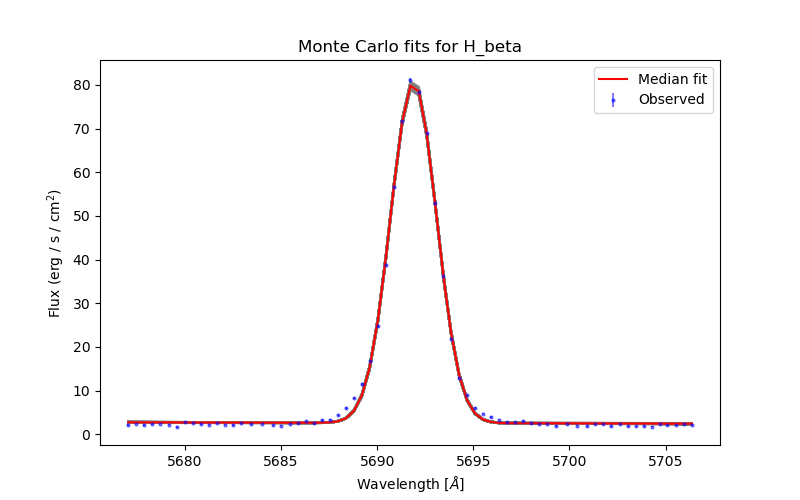

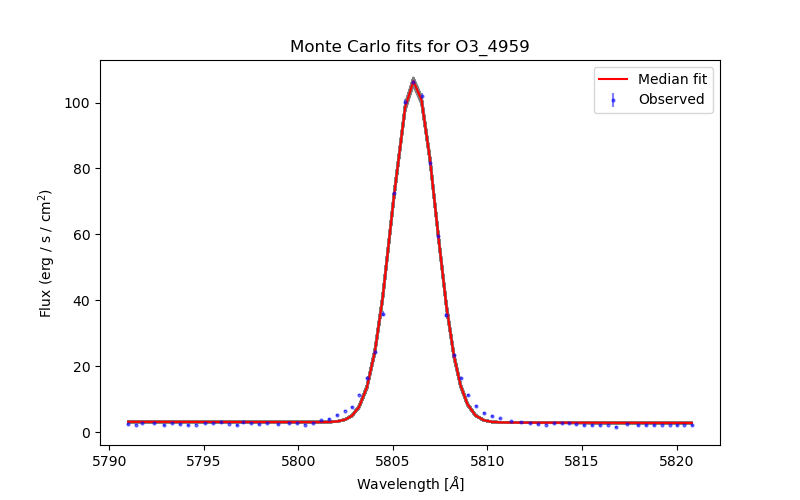

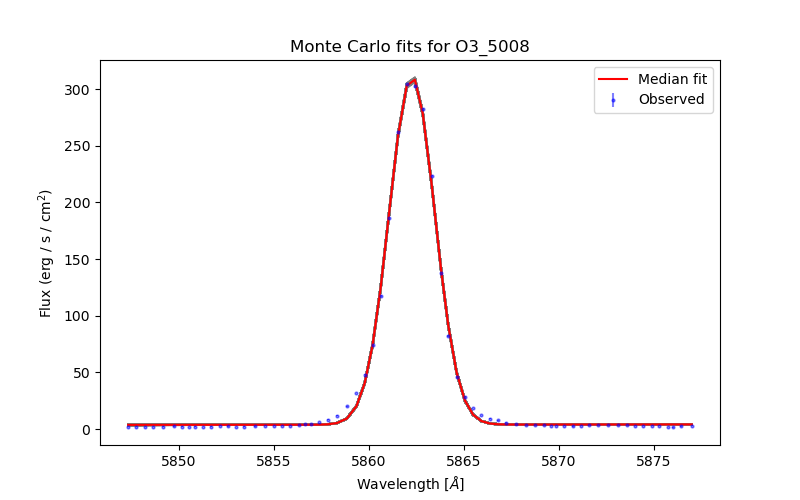

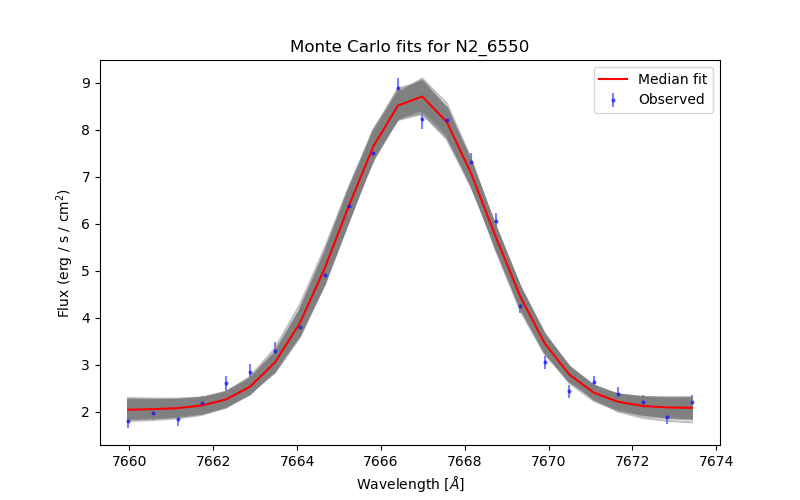

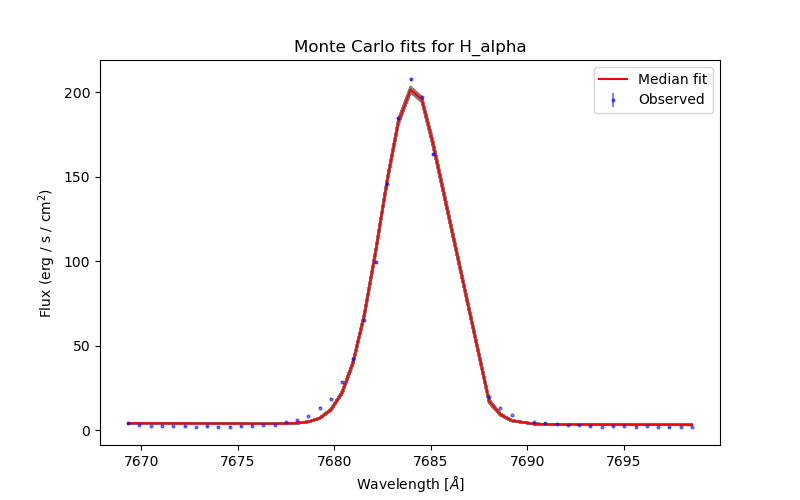

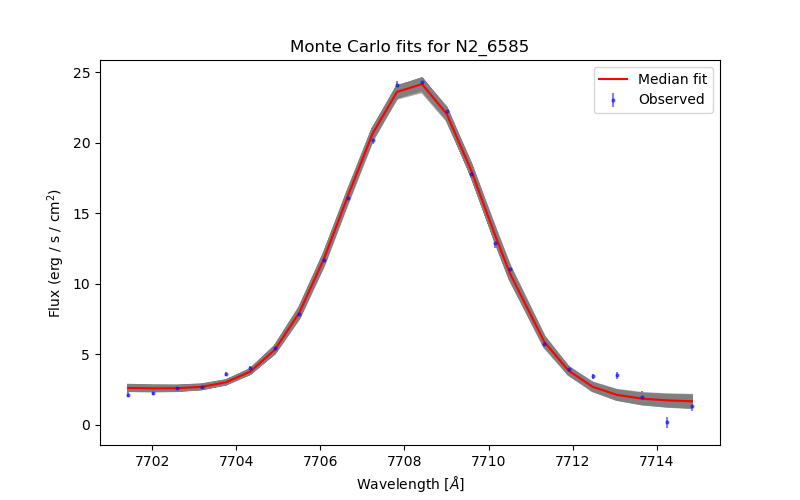

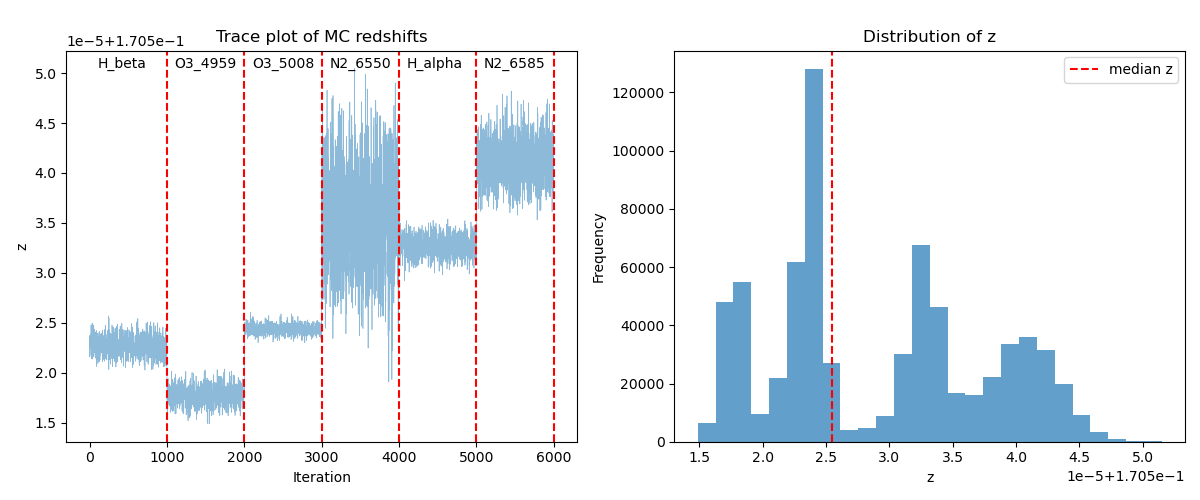

New redshift calculated for no_very_flats,z = 0.17052548924722377
Executed reset_redshift in 38.5484s


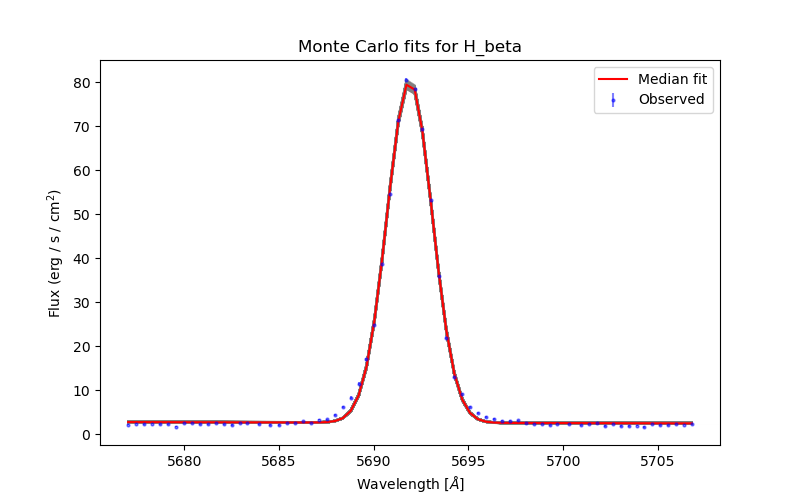

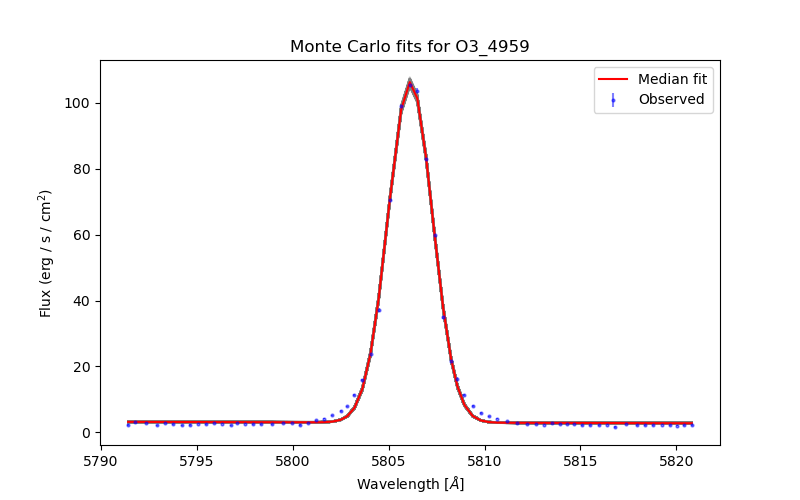

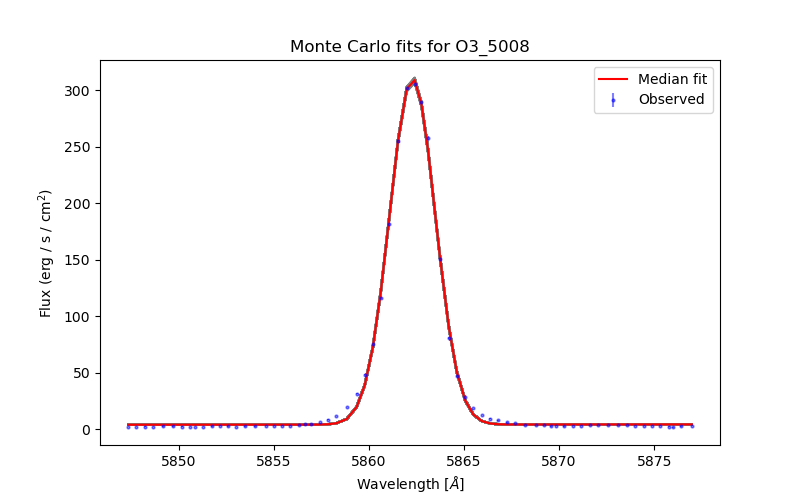

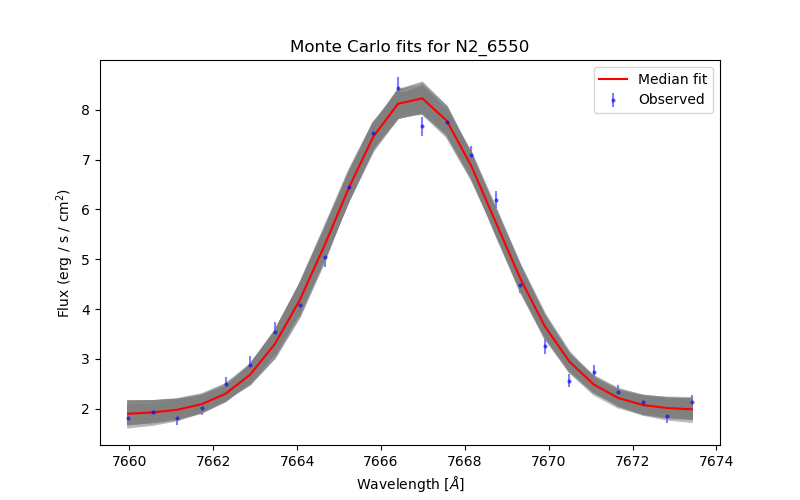

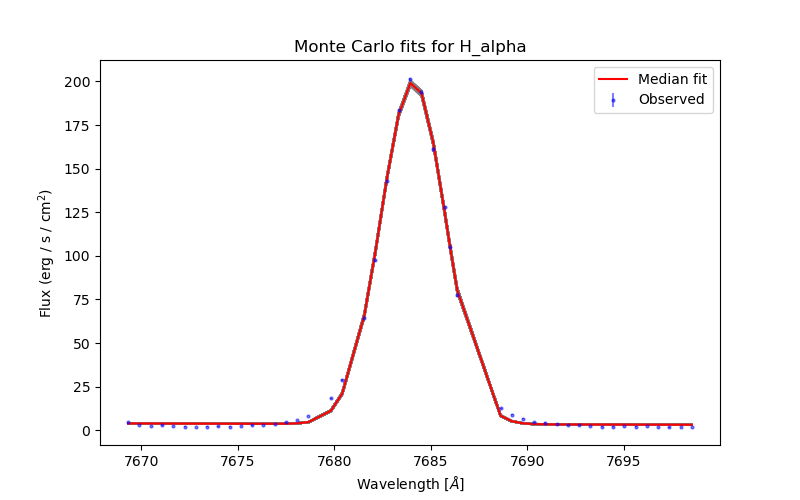

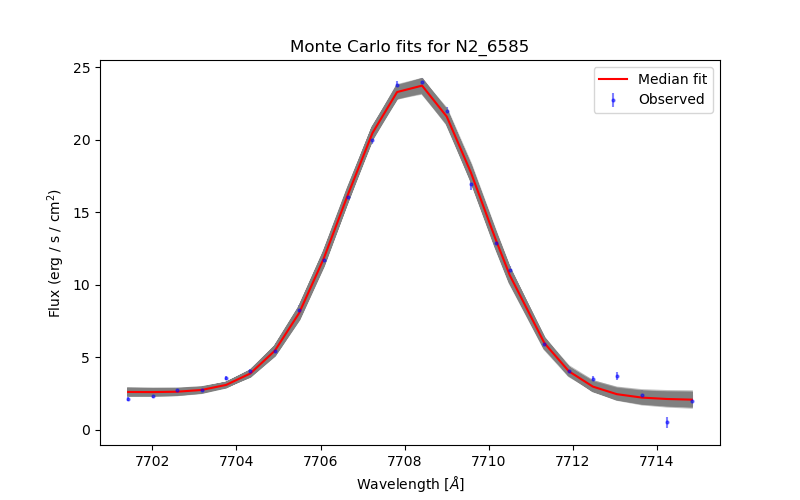

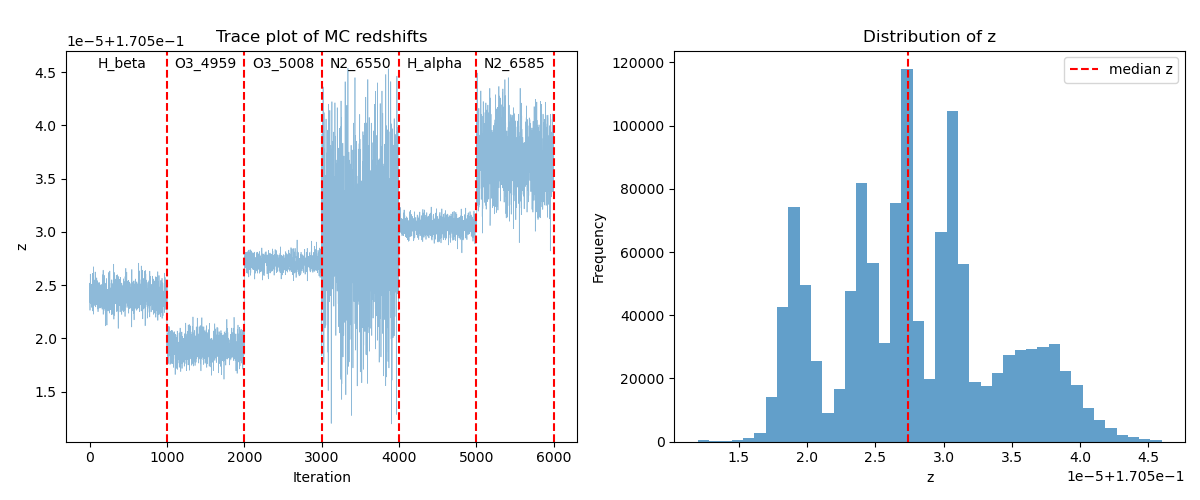

New redshift calculated for twilight,z = 0.1705273930537714
Executed reset_redshift in 38.6241s
New redshift for J2336-0042,z = 0.17052548924722377


In [2]:
J2336_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/7-J2336/',
    'FILES': [ 'no_very_flats/J2336_NO_VERY_BLUE_tellcorr.fits', 'twilight/J2336_TWILIGHT_tellcorr.fits'],
    'redshift':0.17047114835326904,
    'names':['J2336-0042'],
    'mass':9.9
}
J2336 = SPECTRALDATA(J2336_SPECTRA)
Z = REDSHIFT(J2336)


Reading data for J2336
Using MW dust + Balmer abs corrected and continuum substracted data


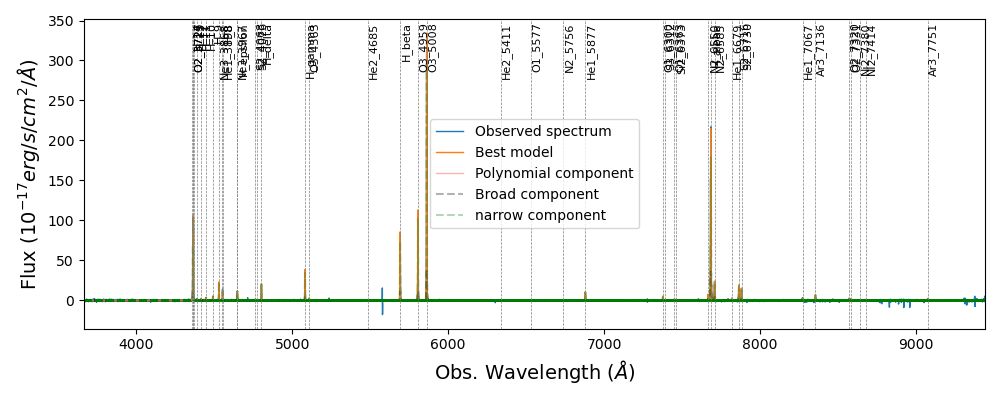

In [3]:
red = REDUC_LINES(J2336)
fit = red.fit_spectra(show_Plot=True)

In [4]:
red.spectra.linelist_dict['N2_6585']

np.float64(6585.2)

/var/folders/b3/z1vmt1t542ncmpppx7tfrqd80000gn/T/ipykernel_62405/795897335.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig2, (ax, ax_res) = plt.subplots(


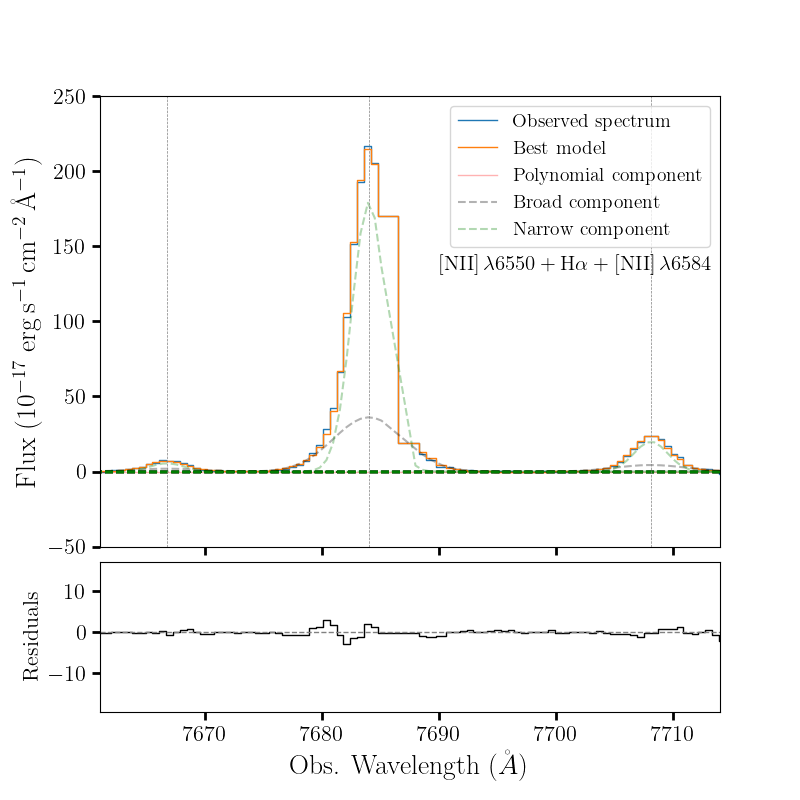

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig2, (ax, ax_res) = plt.subplots(
    2, 1, figsize=(8, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
)

comps = fit.eval_components(x=red.wave)

# --- Main spectrum ---
narrow_key = [key for key, _ in comps.items() if 'narrow' in key]

ax.plot(red.wave, red.flux, lw=1, drawstyle='steps-mid',
        label='Observed spectrum')

ax.plot(red.wave, fit.best_fit, lw=1, drawstyle='steps-mid',
        label='Best model')

ax.plot(red.wave, comps['polynomial'], 'r-',
        label='Polynomial component',
        lw=1, drawstyle='steps-mid', alpha=0.3)

broad_key = [key for key, _ in comps.items() if 'broad' in key]

for i, broad_line in enumerate(broad_key):
    ax.plot(red.wave, comps[broad_line] + comps['polynomial'],
            'k--',
            label='Broad component' if i == len(broad_key)-1 else None,
            alpha=0.3)

for i, narrow_line in enumerate(narrow_key):
    ax.plot(red.wave, comps[narrow_line] + comps['polynomial'],
            'g--',
            label='Narrow component' if i == len(narrow_key)-1 else None,
            alpha=0.3)


# --- Residuals ---
residuals = red.flux - fit.best_fit

ax_res.plot(red.wave, residuals,
            color='black',
            lw=1,
            drawstyle='steps-mid')

ax_res.axhline(0, color='grey', linestyle='--', lw=1)

ax_res.set_ylabel('Residuals', size=16)
ax_res.set_xlabel(r'Obs. Wavelength ($\AA$)', size=20)
# ax_res.set_ylim(-40, 40)


# --- Emission line markers ---
for label in red.spectra.linelist_dict.keys():
    obs_lam = red.spectra.linelist_dict[label] * (1 + red.spectra.redshift)

    ax.axvline(obs_lam, linestyle='--',
               linewidth=0.5, color='grey')


ax.text(0.99, 0.65,
    r'$[\mathrm{NII}]\,\lambda6550 + \mathrm{H\alpha} +[\mathrm{NII}]\,\lambda6584$',
    transform=ax.transAxes,
    fontsize=15,
    color='k',
    ha='right',
    va='top'
)
# --- Formatting ---
ax.set_ylabel(r'Flux ($10^{-17}\ \mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$)', size=20)
obs_lam = red.spectra.linelist_dict['H_alpha'] * (1 + red.spectra.redshift)
ax.set_xlim(obs_lam-23, obs_lam+30)
ax.set_ylim(-50, 250)

ax.legend(fontsize=14, frameon=True, loc='upper right')
ax_res.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6
)
ax.tick_params(
    axis='both',
    which='major',
    labelsize=16,
    width=2,
    length=6, labelbottom=False
)


plt.show()

Reading data for J2336
Using MW dust + Balmer abs corrected and continuum substracted data


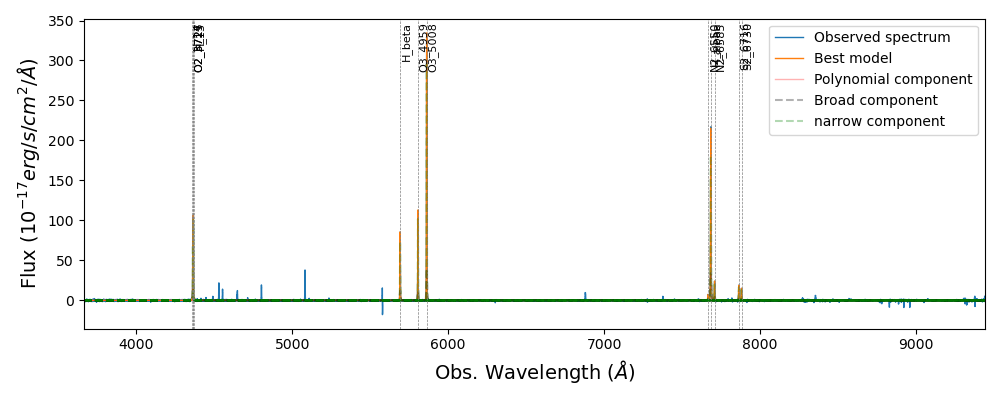

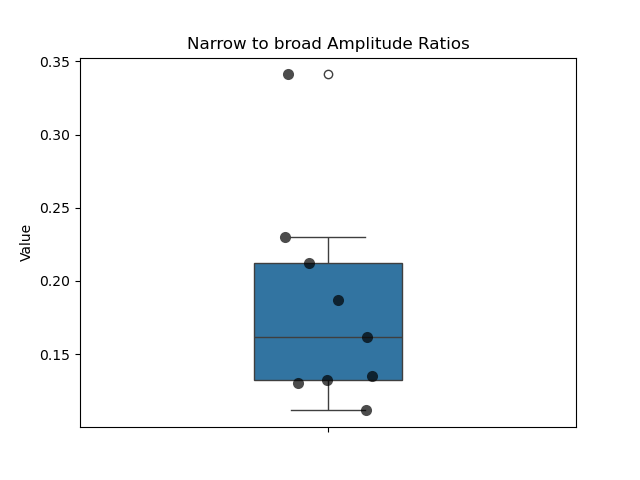

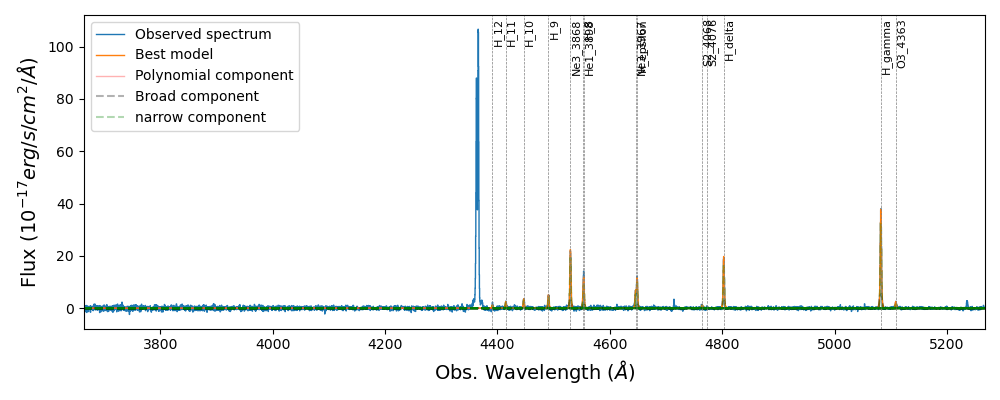

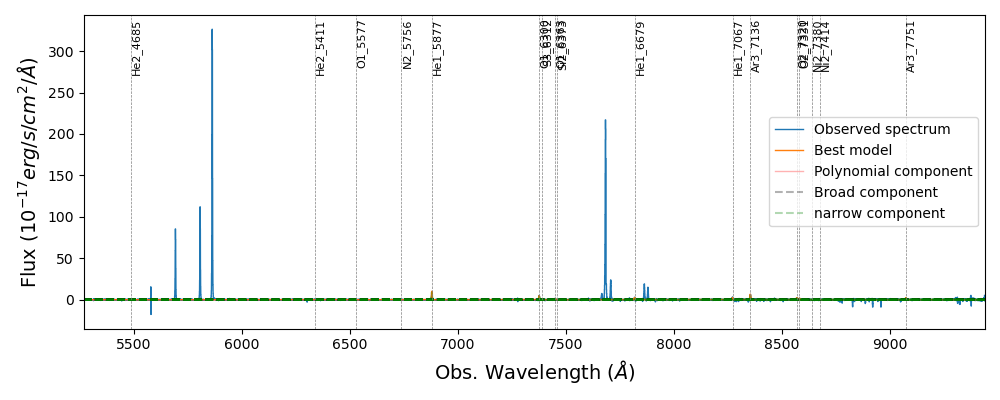

In [3]:
red = REDUC_LINES(J2336)
linelist = red.spectra.linelist_dict
bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                'S2_6716','S2_6730']

bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

mask = (red.wave < 4500*(1+red.spectra.redshift))
wave1, flux1, sigma1 = red.wave[mask], red.flux[mask], red.sigma[mask]
wave2, flux2, sigma2 = red.wave[~mask], red.flux[~mask], red.sigma[~mask]

blue_lines_b = {k:v for k,v in bright_dict.items() if v < 4500}
red_lines_b  = {k:v for k,v in bright_dict.items() if v >= 4500}

blue_lines_f = {k:v for k,v in faint_dict.items() if v < 4500}
red_lines_f  = {k:v for k,v in faint_dict.items() if v >= 4500}

lines = red.spectra.linelist_dict
blue_lines = {k:v for k,v in lines.items() if v < 4500}
red_lines = {k:v for k,v in lines.items() if v >= 4500}


init = fitting_lines(red.wave, red.flux,
                    bright_dict,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=None, A_ratio=None)
ratios = a_ratio_dist(init, plot=True)

out_blue = fitting_lines(wave1, flux1,
                    blue_lines_f,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

out_red = fitting_lines(wave2, flux2,
                    red_lines_f,
                    z_init=red.spectra.redshift,plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [4]:
save_data(red, 100)

Starting MC iteration
Saving in /Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J2336/


,ID,mass,z_red,z_blue,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J2336-0042,9.9,0.170525,0.17051,H_14,10.564559,0.377181,0.894139,0.701979,9.605309,0.856870
1,J2336-0042,9.9,0.170525,0.17051,O2_3725,201.459863,1.126870,124.752460,6.446555,76.807722,6.408163
2,J2336-0042,9.9,0.170525,0.17051,O2_3727,233.758739,1.393944,173.611921,6.458328,60.157172,6.753111
3,J2336-0042,9.9,0.170525,0.17051,H_13,10.081203,0.492231,0.243131,0.520173,9.764200,0.797650
4,J2336-0042,9.9,0.170525,0.17051,H_12,2.748330,0.261650,2.748330,0.261650,0.000000,0.000000
5,J2336-0042,9.9,0.170525,0.17051,H_11,5.146720,0.331367,5.146720,0.331367,0.000000,0.000000
6,J2336-0042,9.9,0.170525,0.17051,H_10,7.469814,0.261730,7.469814,0.261730,0.000000,0.000000
7,J2336-0042,9.9,0.170525,0.17051,H_9,10.868468,0.324539,10.868468,0.324539,0.000000,0.000000
8,J2336-0042,9.9,0.170525,0.17051,Ne3_3868,47.477079,0.699344,47.477079,0.699344,0.000000,0.000000
9,J2336-0042,9.9,0.170525,0.17051,He1_3898,22.314120,0.520628,22.314120,0.520628,0.000000,0.000000


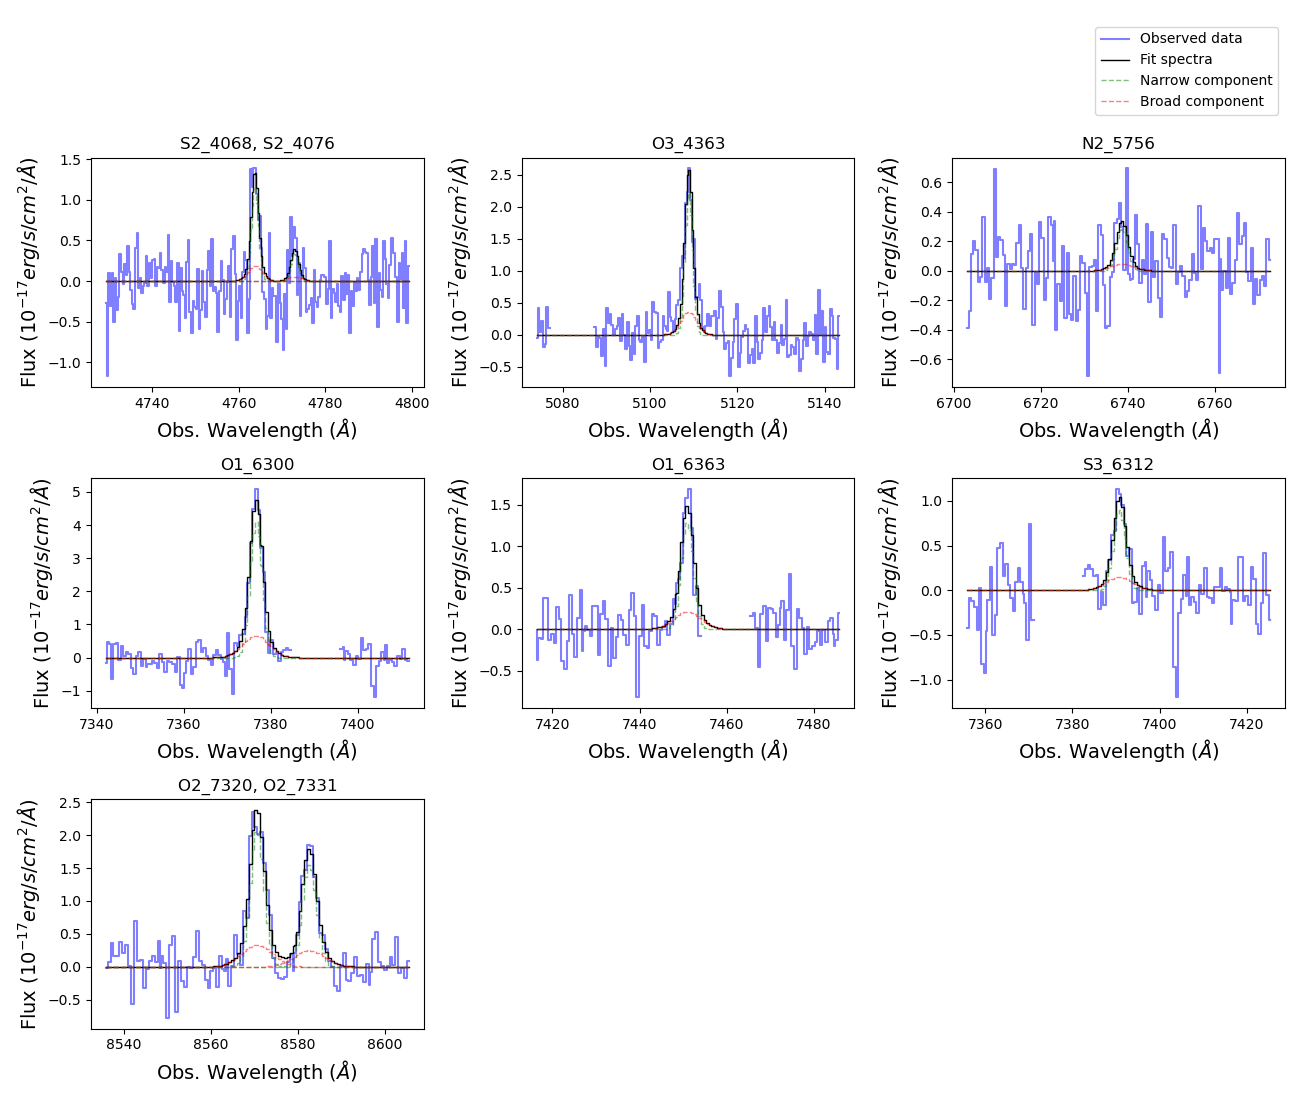

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/new_lines.py:542: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


In [5]:
a, b = fit_auroral_new(red, ratio=ratios, flux_=red.flux, showplot=True)
info, res = save_data_auroral_MC(red, ratio=ratios, num=100)

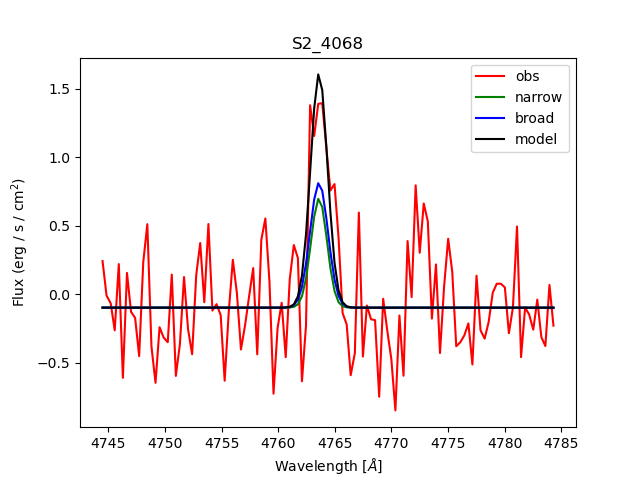

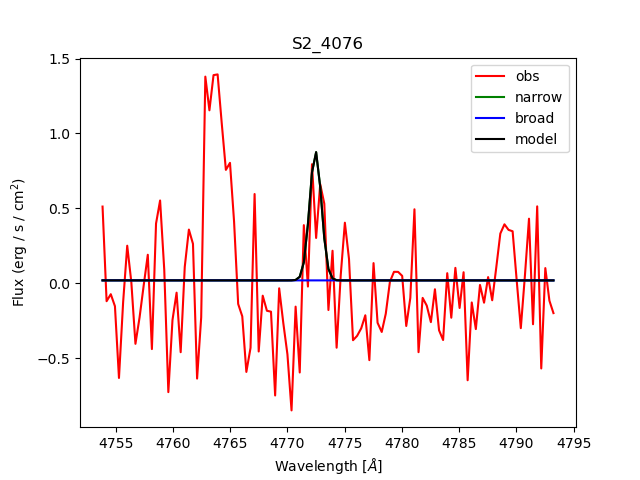

In [3]:
from astropy.io import fits
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# get data
name= 'J2336'
save_path = f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/{name}/cont_corr_{name}.csv'
dcorr = pd.read_csv(save_path)
wave, flux, sigma = dcorr['wave'], dcorr['flux'], dcorr['sigma']

# stamp
labels = 'S2_4068', 'S2_4076'
class_ = J2336
df = pd.read_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')
for label in labels:
    wave_rest = class_.linelist_dict[label]
    wave_obs = wave_rest * (1 + class_.redshift)
    mask = ((wave > wave_obs - 20) & (wave < wave_obs + 20))
    wave_stamp, flux_stamp = wave[mask], flux[mask]
    sigma_stamp = dcorr['sigma'][mask]

    # model
    narrow_gaussian = GaussianModel(prefix=label+'_narrow_')
    broad_gaussian = GaussianModel(prefix=label+'_broad_')

    # Create a polynomial model for the continuum
    polydeg = 1
    polynomial = PolynomialModel(degree=polydeg)

    sum_of_gaussians = narrow_gaussian + broad_gaussian

    comp_mult = sum_of_gaussians + polynomial
    pars_mult = comp_mult.make_params()

    pars_mult.add(name='z', value=class_.redshift, vary=True)

    pars_mult.add(name='sigma_v_narrow', value=30, min=20, max=50)
    pars_mult.add(name='sigma_v_broad', value=60, min=50, max=70)

    for param in ['center', 'amplitude', 'sigma']:
        narrow_key = f'{label}_narrow_{param}'
        if param == 'center':
            value = wave_rest
            vary = True
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 1
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_narrow/3e5)*{label}_narrow_center'
        pars_mult[narrow_key] = Parameter(name=narrow_key, value=value,
                                            vary=vary, expr=expr,
                                            min=0.0)


    for param in ['center', 'amplitude', 'sigma']:
        broad_key = f'{label}_broad_{param}'
        if param == 'center':
            value = wave_rest
            vary = False
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 0.3
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_broad/3e5)*{label}_broad_center'
        pars_mult[broad_key] = Parameter(name=broad_key,
                                            value=value, min=0.0,
                                            vary=vary, expr=expr)

    for i in range(polydeg+1):
        pars_mult[f'c{i:1.0f}'].set(value=0)

    comps = []
    for i in range(100):
        y_off = flux_stamp + np.random.randn(len(flux_stamp)) * sigma_stamp
        out_comp_mult = comp_mult.fit(y_off, pars_mult, x=wave_stamp,
                                        nan_policy='omit', max_nfev=1000)
        comps.append(out_comp_mult)

    # plot 1
    model = comps[0].eval_components(x=wave_stamp)
    plt.figure()
    plt.plot(wave_stamp, flux_stamp, color='red', label='obs')
    plt.plot(wave_stamp, model[f'{label}_narrow_'] + model['polynomial'], color='green', label='narrow')
    plt.plot(wave_stamp, model[f'{label}_broad_'] + model['polynomial'], color='blue', label='broad')
    plt.plot(wave_stamp, comps[0].best_fit, color='black', label='model')
    plt.title(label)
    plt.xlabel(r"Wavelength [$\AA$]")
    plt.ylabel(r'Flux (erg / s / cm$^{2}$)')
    plt.title(label)
    plt.legend()
    plt.show()

    # Saving
    sum_narr = []
    sum_bro = []
    sum = []
    for comp in comps:
        sum_narr.append(comp.params[f'{label}_narrow_amplitude'].value)
        sum_bro.append(comp.params[f'{label}_broad_amplitude'].value)
        sum.append(comp.params[f'{label}_narrow_amplitude'].value + comp.params[f'{label}_broad_amplitude'].value)
    median_narr = np.median(sum_narr)
    std_narr = np.std(sum_narr)

    median_bro = np.median(sum_bro)
    std_bro = np.std(sum_bro)

    median = np.median(sum)
    std = np.std(sum)

    new_row ={
        'ID':df['ID'][0],
        'mass': df['mass'][0],
        'z':df['z'][0],
        'name':label,
        'flux':median,
        'fluxerr':std,
        'narrow_flux':median_narr,
        'narrow_fluxerr':std_narr,
        'broad_flux':median_bro,
        'broad_fluxerr':std_bro
    }
    df.loc[len(df)] = new_row
df.to_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')

Reading data for J2336
Using MW dust + Balmer abs corrected and continuum substracted data


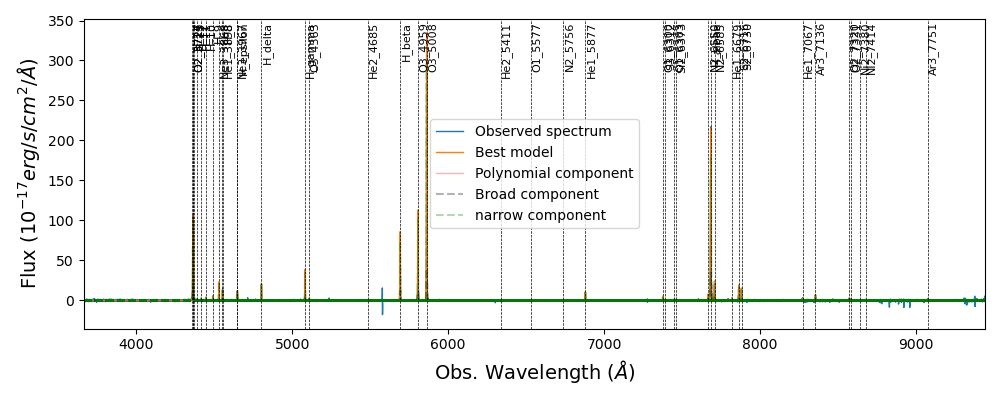

In [5]:
red = REDUC_LINES(J2336)
fit = red.fit_spectra(show_Plot=True)

In [4]:
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['H_beta']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_5008']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['O3_4363']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6550']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (Z.z_chain.max() - Z.z_chain.min()) * red.spectra.linelist_dict['N2_6585']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))

2.568965148736396
1.9029520760062313
1.9599112230344617
1.707968255966273
2.5632042443527037
2.5770613094689288


Calculating the first initial params
Starting MC iteration
Executed fit_MC in 1061.9986s


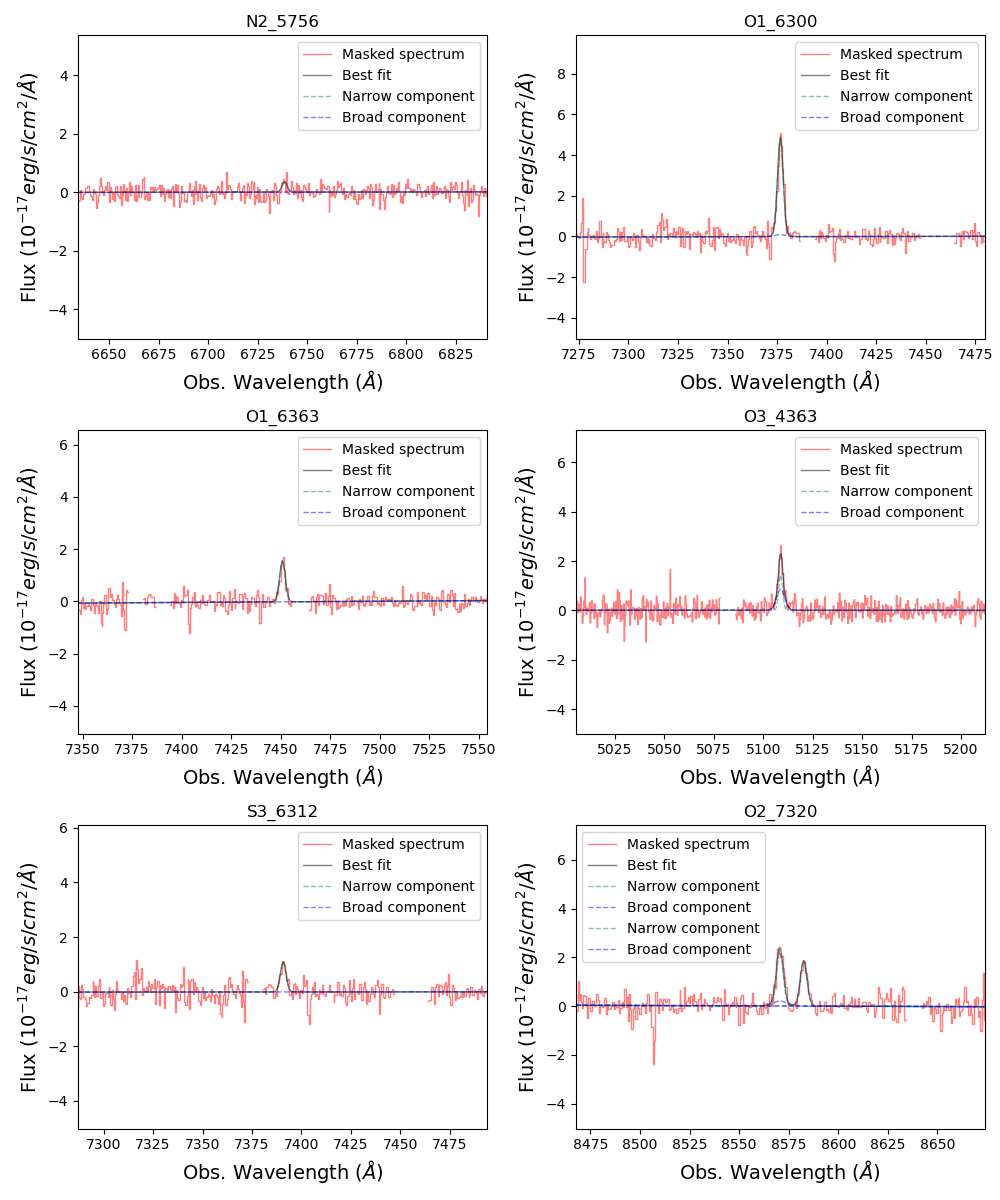

,sigma_v_narrow,sigma_v_broad,N2_5756_narrow_amplitude,N2_5756_broad_amplitude,O1_6300_narrow_amplitude,O1_6300_broad_amplitude,O1_6363_narrow_amplitude,O1_6363_broad_amplitude,O3_4363_narrow_amplitude,O3_4363_broad_amplitude,S3_6312_narrow_amplitude,S3_6312_broad_amplitude,O2_7320_narrow_amplitude,O2_7320_broad_amplitude,O2_7331_narrow_amplitude,O2_7331_broad_amplitude
0,58.003633,119.515002,1.168866,3.080048e-08,17.17397,0.711813,5.651688,1.041763e-08,3.571065,4.410719,3.945049,0.000002,9.256496,1.726117,7.782504,0.000001


In [7]:
red.fit_MC(numMC=100)
red.fit_auroral(red.wave, red.flux, showplot=True)


In [8]:
red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:381: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 19.1593s


,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J2336-0042,9.9,0.170525,N2_5756,1.232416,0.256612,1.156726,0.354049,9.626265e-07,0.410947
1,J2336-0042,9.9,0.170525,O1_6363,5.710277,0.340794,5.648756,0.315110,1.121410e-07,0.274947
2,J2336-0042,9.9,0.170525,O3_4363,7.998672,0.411018,3.646385,0.538990,4.370576e+00,0.763312
3,J2336-0042,9.9,0.170525,S3_6312,4.050150,0.376002,3.783666,0.465506,2.969098e-05,0.577254
4,J2336-0042,9.9,0.170525,O2_7320,10.919276,0.510798,9.349641,0.628787,1.580028e+00,0.905099
5,J2336-0042,9.9,0.170525,O2_7331,7.837845,0.416887,7.627620,0.459831,6.858047e-07,0.405120
6,J2336-0042,9.9,0.170525,O2_7320_7331,18.767426,0.736055,16.962532,0.806089,1.797850e+00,1.008136


Performing dust correction for J2336
Extinction correction done! Using total curve.


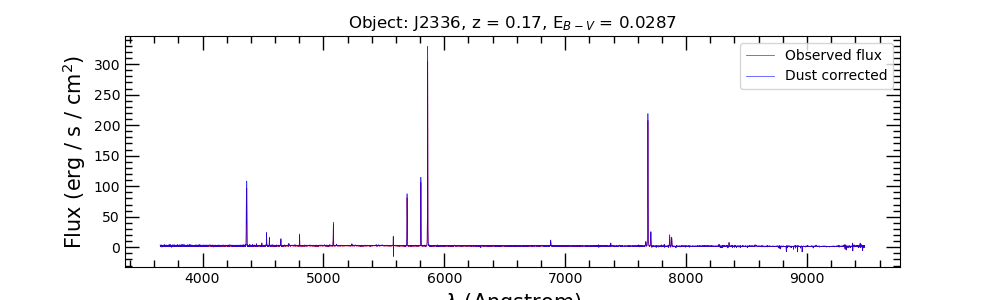

Saved figure at: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J2336/dcorr_J2336.pdf
Using uncorrected data


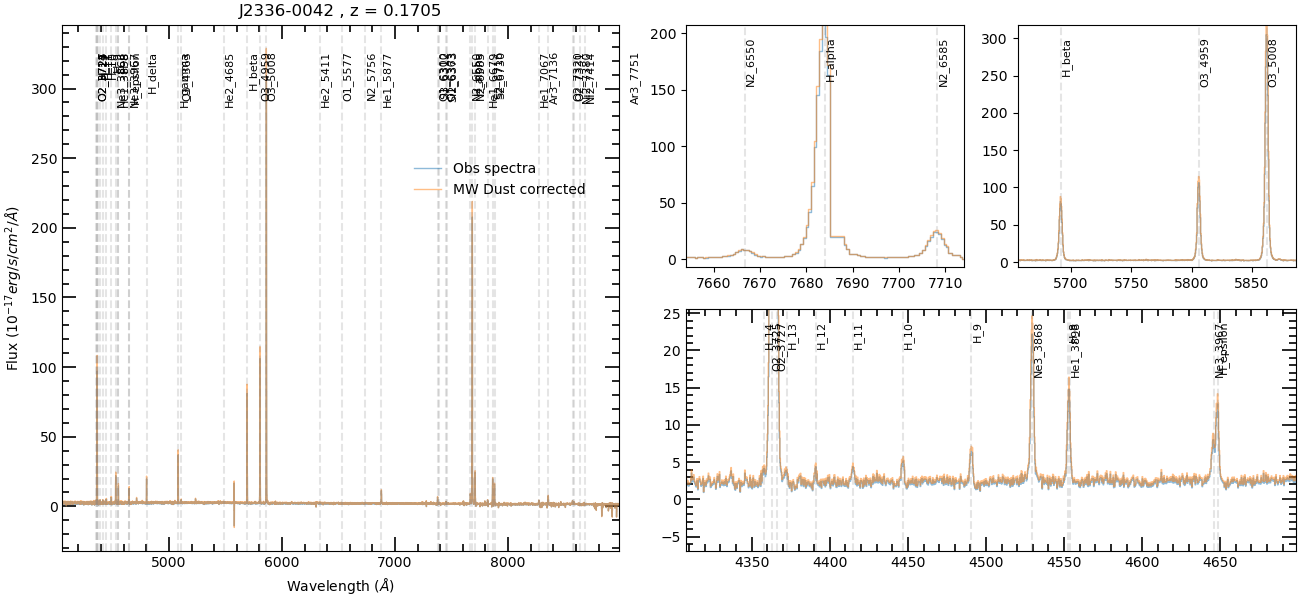

Saved MW dust corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J2336/dcorr_J2336.csv
Executed MW_dust_corr in 0.8883s


In [3]:
MW_DUST_CORR(J2336, plot=True)

Reading data for J2336
Using MW dust corrected data
Performing Balmer absorption correction for J2336


/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:465: RuntimeWarning: divide by zero encountered in divide
  weights=1/self.sigma**2,


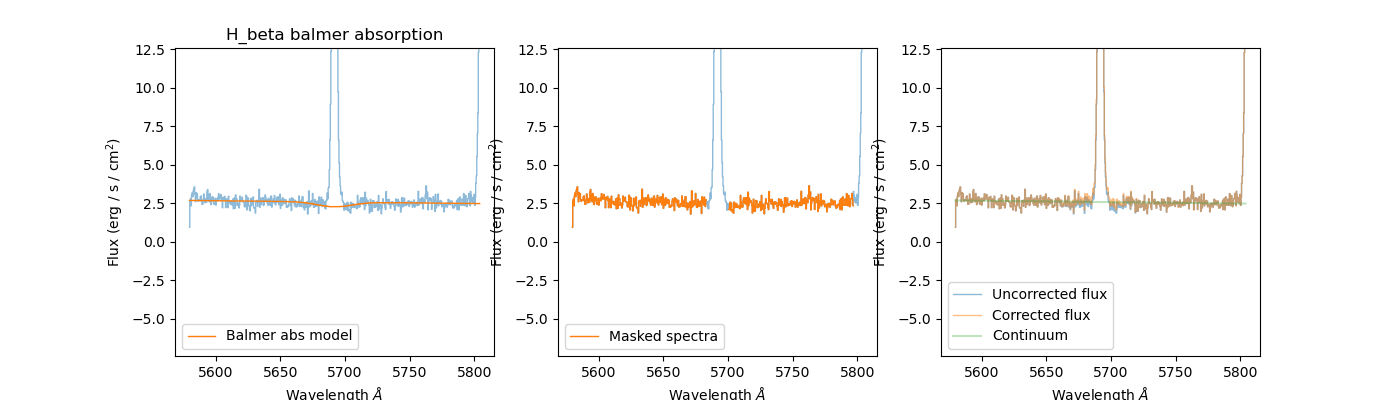

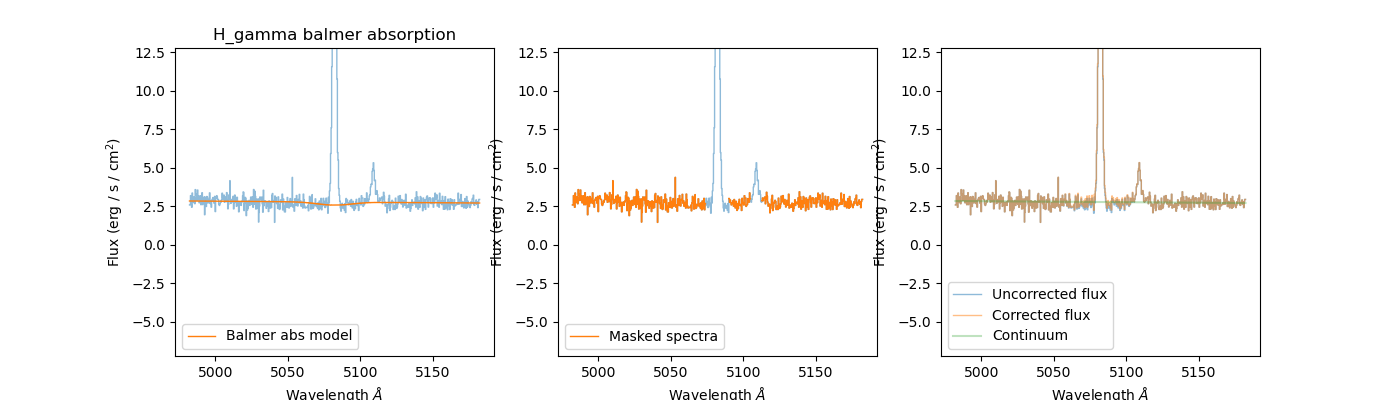

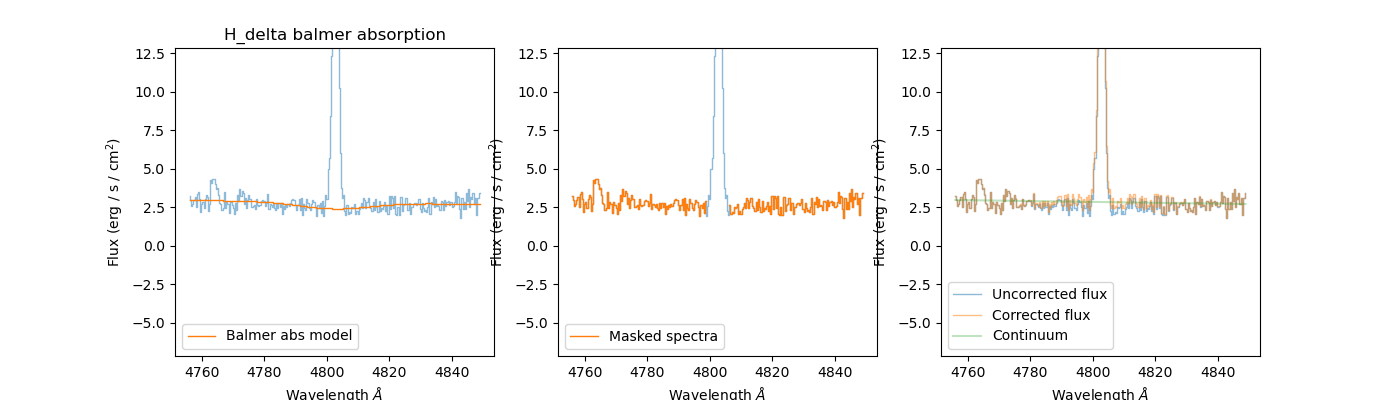

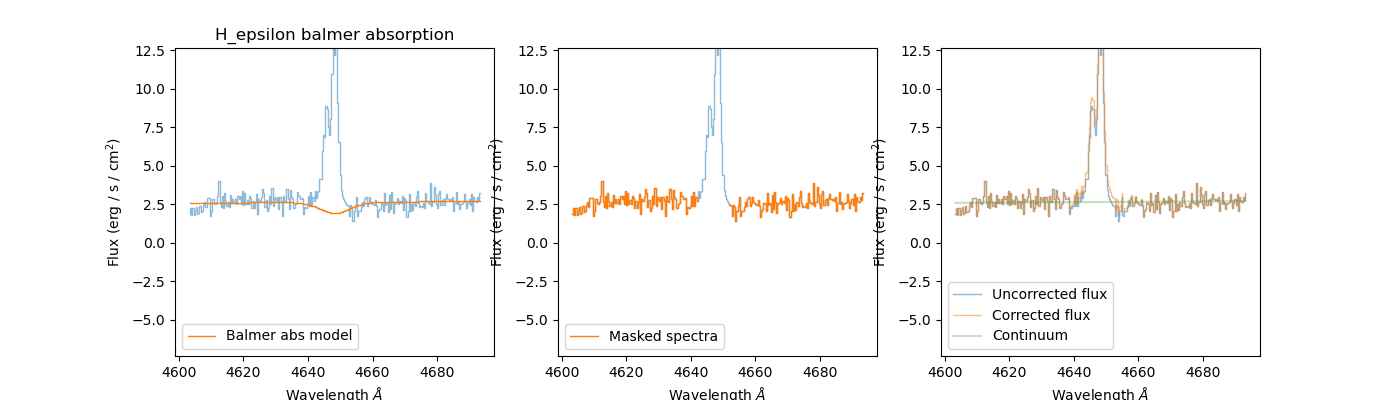

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:608: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, axs = plt.subplots(1, 3, figsize=(14, 4))


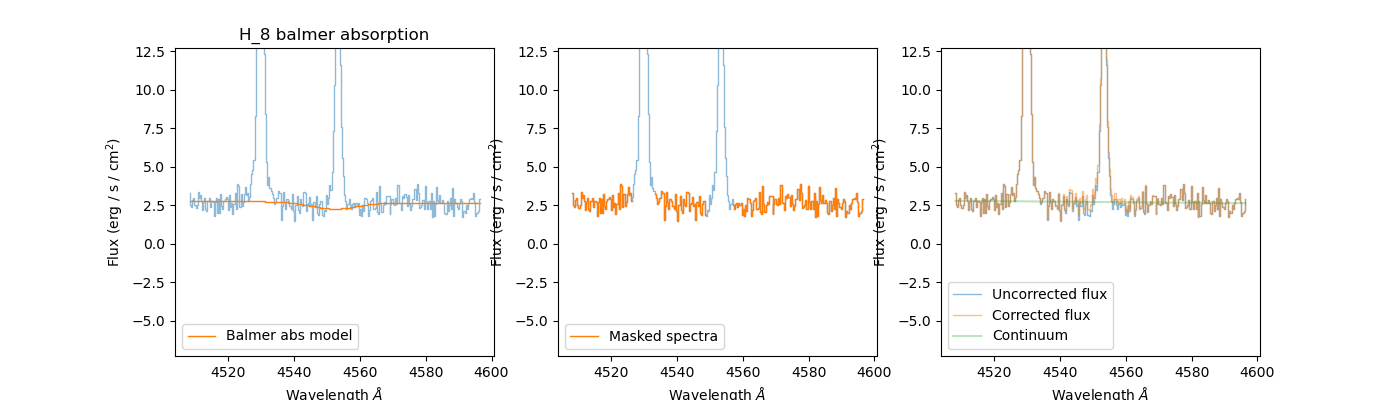

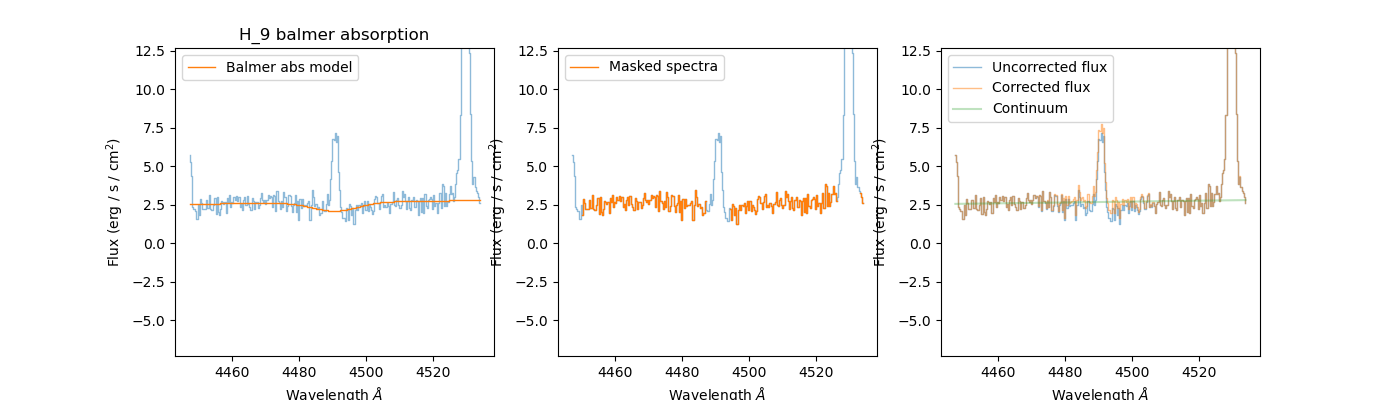

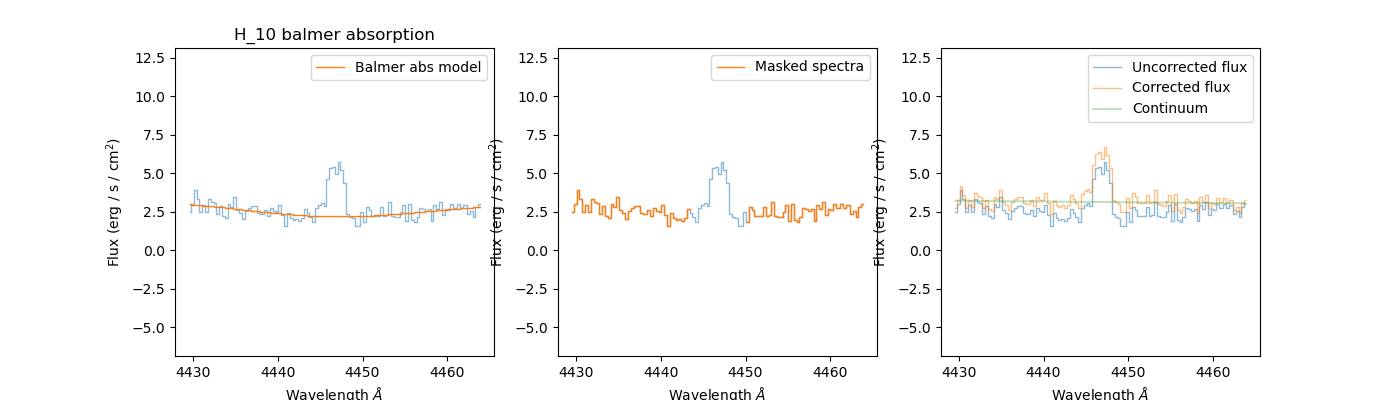

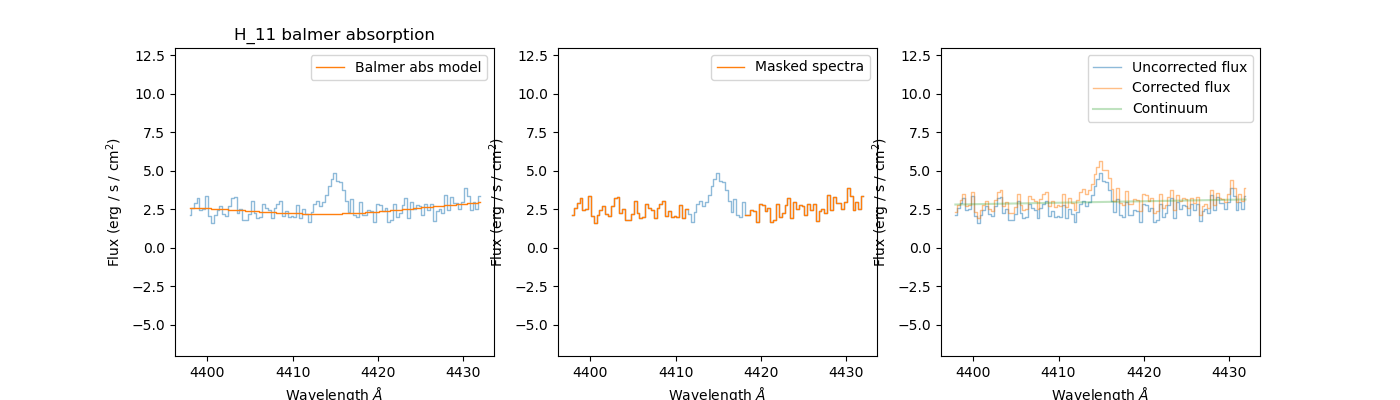

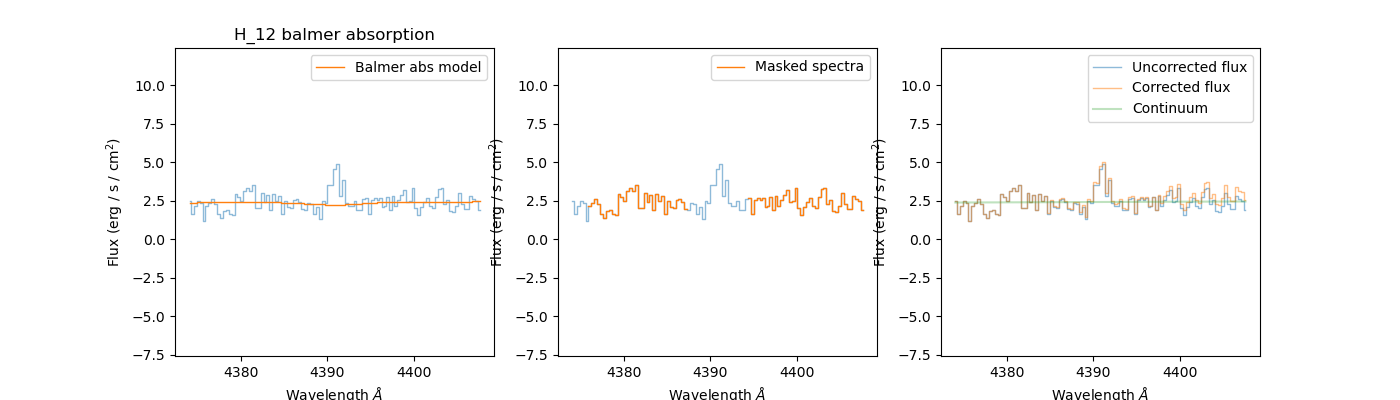

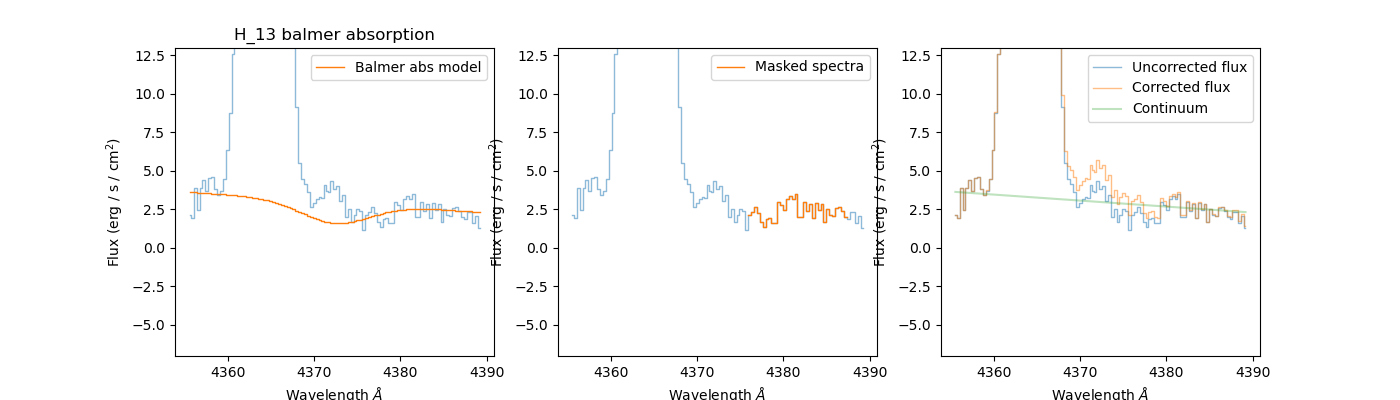

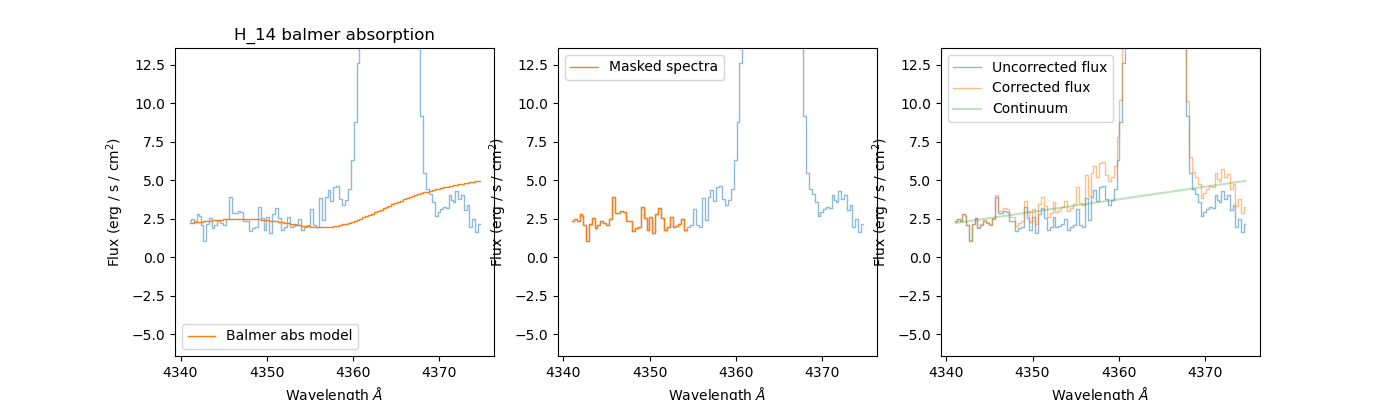

Using MW dust + Balmer abs corrected  data


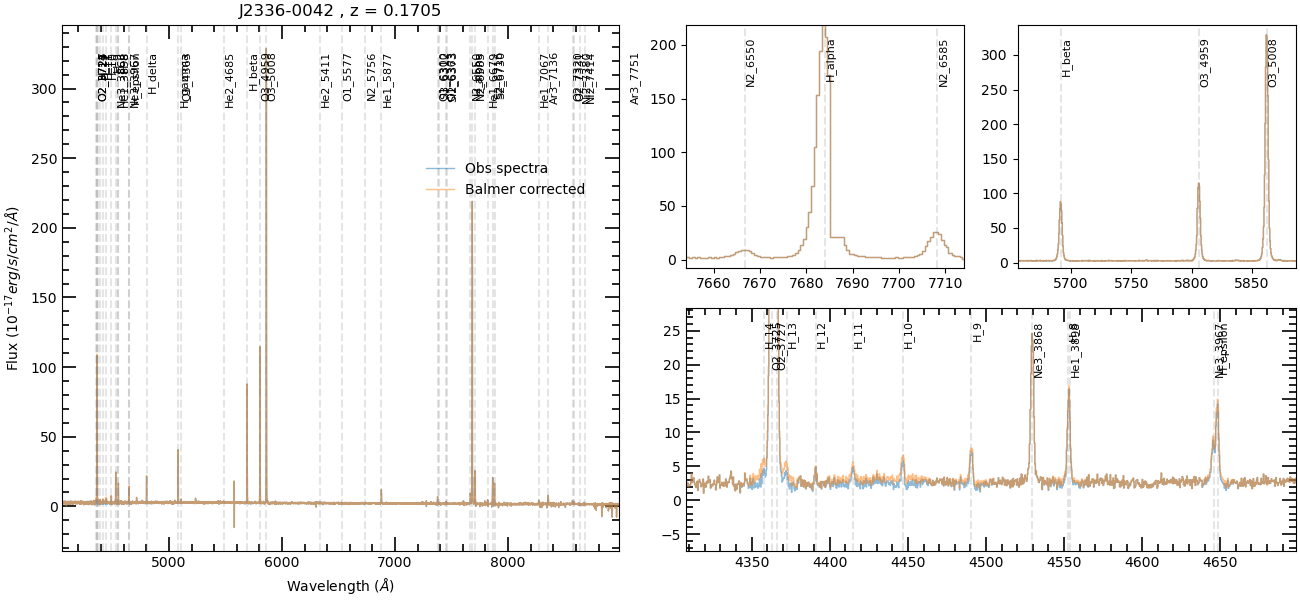

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J2336.csv
Balmer absorption correction done!
Executed bal_abs_corr in 13.8355s


In [4]:
b = BALMER_ABS(J2336, showplot=True)

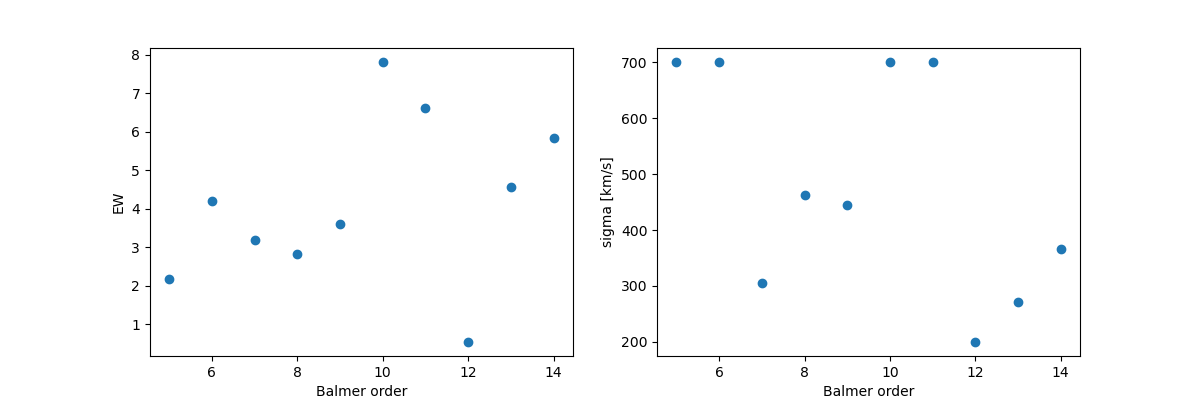

,ID,z,name,sigma,EW
0,J2336-0042,0.170525,H_beta,700.000000,-4.017427
1,J2336-0042,0.170525,H_gamma,700.000000,-2.179044
2,J2336-0042,0.170525,H_delta,700.000000,-4.209954
3,J2336-0042,0.170525,H_epsilon,305.555335,-3.190097
4,J2336-0042,0.170525,H_8,461.643823,-2.824998
5,J2336-0042,0.170525,H_9,444.277284,-3.604923
6,J2336-0042,0.170525,H_10,700.000184,-7.809742
7,J2336-0042,0.170525,H_11,700.000787,-6.609967
8,J2336-0042,0.170525,H_12,199.999776,-0.536579
9,J2336-0042,0.170525,H_13,272.092924,-4.553409


In [5]:
b.EW()

Reading data for J2336
Using MW dust + Balmer abs corrected  data
Calculating the first initial params


/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:916: RuntimeWarning: divide by zero encountered in divide
  weights=1/self.sigma**2,


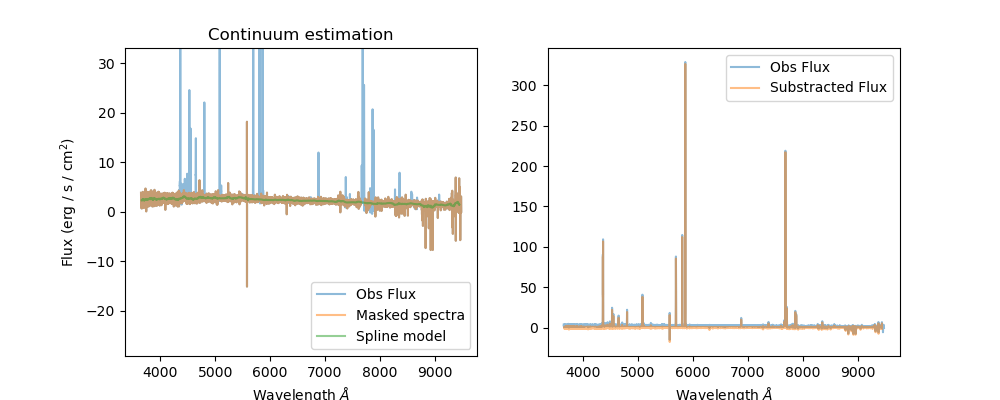

Executed cont_est in 10.7959s
Using MW dust + Balmer abs corrected and continuum substracted data


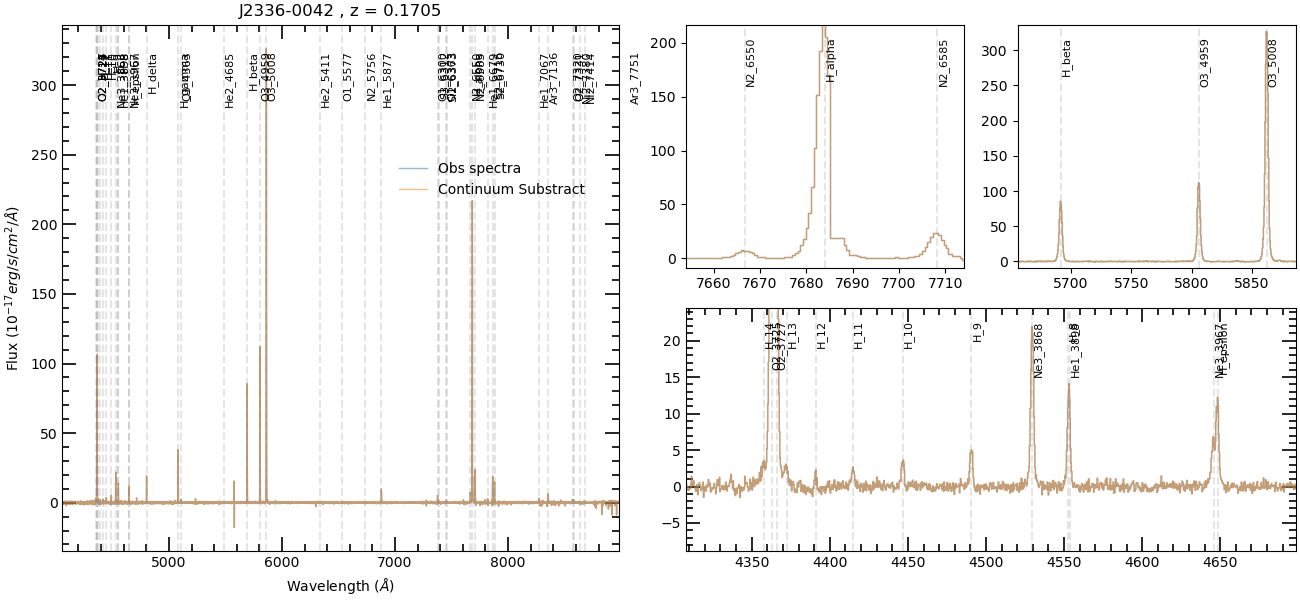

Saved continuum substracted data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J2336/cont_corr_J2336.csv


In [4]:
CONTINUUM_SUBSTRACT(J2336)

Reading data for J2336
Using MW dust + Balmer abs corrected and continuum substracted data


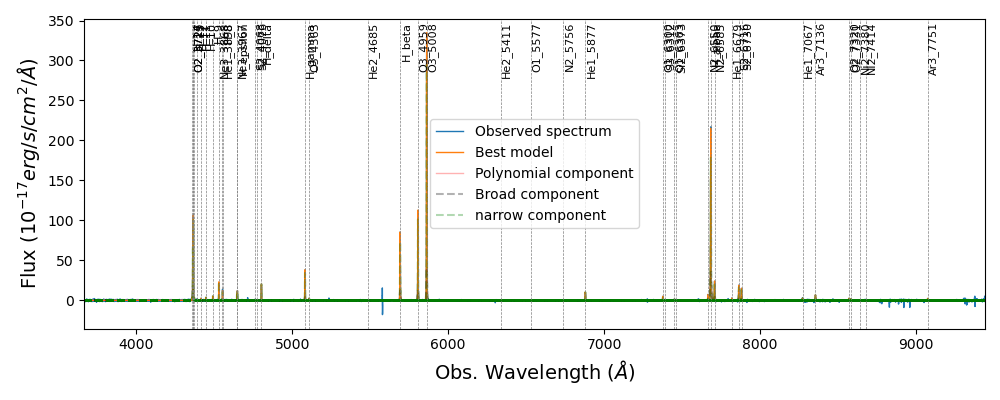

In [3]:
red = REDUC_LINES(J2336)
fit = red.fit_spectra(show_Plot=True)

In [ ]:
red.fit_MC(numMC=100)

Starting MC iteration


/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:112: RuntimeWarning: divide by zero encountered in divide
  weights=1/self.sigma**2,


Executed fit_MC in 1341.1702s


In [5]:
red.fit_auroral(red.wave, red.flux, showplot=True)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J2336/J2336_iter_.csv'

In [5]:
df = red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:454: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 35.7652s
